# 中間表現の最適化

このノートブックでは、`qret opt` を使って中間表現（IR）を最適化する手順を確認します。
`qret opt` の実行方法は次の 2 つです。

- `--pass` を並べて直接実行する。
- YAML パイプラインで pass と外部コマンドをまとめて実行する。

本章の目標は次のとおりです。

- `Call` のインライン展開（1 段・再帰）を比較する。
- `ir::decompose_inst` で高レベル命令を低レベル命令へ分解する。
- `ir::static_condition_pruning` で分岐を静的簡約する。
- 外部 pass をパイプラインへ接続する。


まず、実行パスと入力ファイルを設定します。
`exe_path` と `GRIDSYNTH_PATH` は環境に合わせて変更してください。
また、Qurationに添付されているgridsynthを利用する場合は、必要に応じて実行権限を付与してください。

In [1]:
import pathlib
import platform

import graphviz
from IPython.display import Code
import os

project_root = pathlib.Path("../..").resolve()
if platform.system() == "Windows":
    qret_path = project_root / "build" / "bin"
    gridsynth_path = project_root / "externals" / "bin" / "gridsynth.exe"
elif platform.system() == "Darwin": 
    qret_path = project_root / "build" / "main"
    gridsynth_path = project_root / "externals" / "bin" / "gridsynth_macos"
elif platform.system() == "Linux":
    qret_path = project_root / "build" / "main"
    gridsynth_path = project_root / "externals" / "bin" / "gridsynth"
else:
    raise ValueError("Unsupported platform")
data_path = "data/tutorial_3.json"

os.environ["GRIDSYNTH_PATH"] = str(gridsynth_path)
os.environ["PATH"] = str(qret_path) + os.pathsep + os.environ.get("PATH", "")

`qret` と `gridsynth` が実行可能で、入力 JSON を読み込めることを先に確認します。

In [2]:
!qret --version

Quration: Quantum Resource Estimation Toolchain for FTQC version 1.0.0


In [3]:
!{gridsynth_path} --help

Usage: gridsynth [OPTION...] <theta>
Arguments:
 <theta>                   z-rotation angle. May be symbolic, e.g. pi/128
Options:
  -h        --help          print usage info and exit
  -d <n>    --digits=<n>    set precision in decimal digits (default: 10)
  -b <n>    --bits=<n>      set precision in bits
  -e <n>    --epsilon=<n>   set precision as epsilon (default: 1e-10)
  -p        --phase         decompose up to a global phase (default: no)
  -f "<n>"  --effort="<n>"  how hard to try to factor (default: 25)
  -x        --hex           output hexadecimal coding (default: ASCII)
  -s        --stats         output statistics
  -l        --latex         use LaTeX output format
  -t        --table         generate the table of results for the article
  -c <n>    --count=<n>     repeat count for --table mode (default: 50)
  -r "<s>"  --rseed="<s>"   set optional random seed (default: random)


In [4]:
Code(filename=data_path, language="JSON")

{
    "name": "Tutorial3Module",
    "circuit_list": [
        {
            "name": "Tutorial3Function",
            "entry_point": "entry",
            "bb_list": [
                {
                    "name": "entry",
                    "inst_list": [
                        {
                            "opcode": "Call",
                            "callee": "Toffoli",
                            "operate": [
                                0,
                                1,
                                2
                            ],
                            "input": [],
                            "output": []
                        },
                        {
                            "opcode": "Call",
                            "callee": "RZ_0.1",
                            "operate": [
                                1
                            ],
                            "input": [],
                            "output": []
                        },
                        {
                            "opcode": "Call",
                            "callee": "RZ_0.01",
                            "operate": [
                                2
                            ],
                            "input": [],
                            "output": []
                        },
                        {
                            "opcode": "Return"
                        }
                    ],
                    "predecessors": [],
                    "successors": []
                }
            ],
            "argument": {
                "num_qubits": 3,
                "qubits": {
                    "x": 3
                },
                "num_registers": 1,
                "registers": {
                    "r": 1
                }
            },
            "num_tmp_registers": 0
        },
        {
            "name": "Toffoli",
            "entry_point": "entry",
            "bb_list": [
                {
                    "name": "entry",
                    "inst_list": [
                        {
                            "opcode": "CCX",
                            "q0": 0,
                            "q1": 1,
                            "q2": 2
                        },
                        {
                            "opcode": "Return"
                        }
                    ],
                    "predecessors": [],
                    "successors": []
                }
            ],
            "argument": {
                "num_qubits": 3,
                "qubits": {
                    "x": 3
                },
                "num_registers": 0
            },
            "num_tmp_registers": 0
        },
        {
            "name": "RZ_0.1",
            "entry_point": "entry",
            "bb_list": [
                {
                    "name": "entry",
                    "inst_list": [
                        {
                            "opcode": "RZ",
                            "q": 0,
                            "theta": {
                                "value": 0.2,
                                "precision": 0.1
                            }
                        },
                        {
                            "opcode": "Return"
                        }
                    ],
                    "predecessors": [],
                    "successors": []
                }
            ],
            "argument": {
                "num_qubits": 1,
                "qubits": {
                    "x": 1
                },
                "num_registers": 0
            },
            "num_tmp_registers": 0
        },
        {
            "name": "RZ_0.01",
            "entry_point": "entry",
            "bb_list": [
                {
                    "name": "entry",
                    "inst_list": [
                        {
                            "opcode": "Call",
                            "callee": "RZ_0.01_impl",


次に `opt` コマンドのオプションを確認します。

`qret opt` の実行形態は次の 2 つです。

- **引数直接指定**: `--pass` を複数回指定し、1 回の実行で順に適用します。
- **パイプラインファイル**: YAML に順序と入出力を定義して実行します。

まずは `--help` で利用可能なオプションを確認します。


In [5]:
!qret opt --help

qret 'opt' options:
  -h [ --help ]                         Show this help and exit.
  --quiet                               Suppress non-error output.
  --verbose                             Enable verbose logging (more detail 
                                        than default).
  --debug                               Enable debug logging (most detailed; 
                                        implies --verbose).
  --color                               Enable colored output.
  --pipeline arg                        Pipeline file
  -i [ --input ] arg                    Input file
  -f [ --function ] arg                 Function name to optimize
  -o [ --output ] arg                   Output file
  --ir-static-condition-pruning-seed arg (=0)
                                        Seed of ir::static_condition_pruning 
                                        pass.
  --pass arg                            Optimization pass


## 最適化対象の確認

まず `print -s` で対象モジュールの関数一覧を確認し、最適化対象を `Tutorial3Function` に決めます。

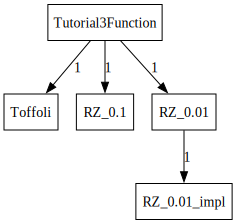

In [6]:
!qret diagram -i {data_path} --function "Tutorial3Function" --graph-format "CallGraph" --display_num_calls -o call_graph.dot

graphviz.Source.from_file("call_graph.dot")

In [7]:
!qret print -i {data_path}

[Module Summary]
  name                  : Tutorial3Module
  function_count        : 5
  functions:
    - RZ_0.01
    - RZ_0.01_impl
    - RZ_0.1
    - Toffoli
    - Tutorial3Function


次に `Tutorial3Function` の未最適化状態を表示し、`Call` 命令の並びを確認します。

In [8]:
!qret print -i {data_path} -f "Tutorial3Function"

[Function]
Tutorial3Function:
 [block] entry
  Call @Toffoli({@q0 @q1 @q2},{},{})
  Call @RZ_0.1({@q1},{},{})
  Call @RZ_0.01({@q2},{},{})
  Return


続いて `-d 2` で呼び出し先まで展開し、展開前後の差分を確認します。

In [9]:
!qret print -i {data_path} -f "Tutorial3Function" -d 2

[Function]
Tutorial3Function:
 [block] entry
  Call @Toffoli({@q0 @q1 @q2},{},{})
  -->
    Toffoli:
     [block] entry
      CCX @q0 @q1 @q2
      Return
  <--  (@Toffoli)
  Call @RZ_0.1({@q1},{},{})
  -->
    RZ_0.1:
     [block] entry
      RZ @q0 0.2 0.1
      Return
  <--  (@RZ_0.1)
  Call @RZ_0.01({@q2},{},{})
  -->
    RZ_0.01:
     [block] entry
      Call @RZ_0.01_impl({@q0},{},{})
      Return
  <--  (@RZ_0.01)
  Return


## Quration に実装済みの pass を適用する場合

ここでは組み込み pass を順に適用し、`print` の出力差分を確認します。
手順は `ir::inliner` -> `ir::recursive_inliner` -> `ir::decompose_inst` -> `ir::static_condition_pruning` です。


`--pass` で直接呼び出せる主な組み込み pass は次のとおりです。

- `ir::inliner`: `Call` を 1 段だけ展開
- `ir::recursive_inliner`: `Call` を再帰的に展開
- `ir::decompose_inst`: 高レベル命令を低レベル命令へ分解
- `ir::static_condition_pruning`: 静的に確定できる分岐を簡約
- `ir::ignore_global_phase`: `GlobalPhase` を除去
- `ir::delete_consecutive_same_pauli`: 同一 Pauli の連続適用を除去
- `ir::delete_opt_hint`: 最適化ヒント命令を除去
- `ir::external`: 外部コマンドを pass として接続


### インライン展開（`Call` 命令の一段展開）

`ir::inliner` は、指定関数内の `Call` を 1 段だけインライン化します。
まずはこの pass 単体で、非再帰展開の結果を確認します。


In [10]:
!qret opt -i {data_path} -o "inlined.json" -f "Tutorial3Function" --pass "ir::inliner"
!qret print -i  "inlined.json" -f "Tutorial3Function" -d 2

[Function]
Tutorial3Function:
 [block] entry
  CCX @q0 @q1 @q2
  RZ @q1 0.2 0.1
  Call @RZ_0.01_impl({@q2},{},{})
  -->
    RZ_0.01_impl:
     [block] entry
      RZ @q0 0.2 0.01
      Return
  <--  (@RZ_0.01_impl)
  Return


### 再帰的インライン展開（`Call` の再帰的置換）

`ir::recursive_inliner` は、展開後に現れた `Call` も続けて展開します。
`ir::inliner` との違いは、呼び出しチェーン全体を潰せる点です。


In [11]:
!qret opt -i {data_path} -o "recursively_inlined.json" -f "Tutorial3Function" --pass "ir::recursive_inliner"
!qret print -i "recursively_inlined.json" -f "Tutorial3Function" -d 2

[Function]
Tutorial3Function:
 [block] entry
  CCX @q0 @q1 @q2
  RZ @q1 0.2 0.1
  RZ @q2 0.2 0.01
  Return


### 回転系命令の分解

`ir::decompose_inst` は、高レベル命令を低レベル命令列へ分解します。
この pass では `GRIDSYNTH_PATH` の設定が必要です。


In [12]:
!qret opt -i {data_path} -o "decomposed.json" -f "Tutorial3Function" --pass "ir::decompose_inst"
!qret print -i "decomposed.json" -f "Tutorial3Function" -d 3

[Function]
Tutorial3Function:
 [block] entry
  Call @Toffoli({@q0 @q1 @q2},{},{})
  -->
    Toffoli:
     [block] entry
      H @q0
      CX @q0 @q1
      TDag @q0
      CX @q0 @q2
      T @q0
      CX @q0 @q1
      TDag @q0
      CX @q0 @q2
      T @q0
      T @q1
      H @q0
      CX @q1 @q2
      TDag @q1
      T @q2
      CX @q1 @q2
      Return
  <--  (@Toffoli)
  Call @RZ_0.1({@q1},{},{})
  -->
    RZ_0.1:
     [block] entry
      I @q0
      Return
  <--  (@RZ_0.1)
  Call @RZ_0.01({@q2},{},{})
  -->
    RZ_0.01:
     [block] entry
      Call @RZ_0.01_impl({@q0},{},{})
      -->
        RZ_0.01_impl:
         [block] entry
          GlobalPhase 0.785398 0
          GlobalPhase 0.785398 0
          GlobalPhase 0.785398 0
          X @q0
          H @q0
          S @q0
          T @q0
          H @q0
          T @q0
          H @q0
          T @q0
          H @q0
          S @q0
          T @q0
          H @q0
          S @q0
          T @q0
          H @q0
          T @q0
        

## 条件分岐の静的簡約
`ir::static_condition_pruning` は、到達時点で確定できる `Branch` / `Switch` を簡約し、到達不能経路を削除します。
本節では `tutorial_2.json` の `DiscreteDistribution` + `Switch` 構造で挙動を確認します。


`tutorial_2.json` の `Tutorial2Function` では、`Switch` の `registers` が `[@r0, @r1]` の順で評価されます。
`r0` が LSB として扱われるため、値は `value = 1*r0 + 2*r1` です。
この対応で `case` / `default` の選択先を読み取れます。


In [13]:
!qret print -i "data/tutorial_2.json" -f "Tutorial2Function"

[Function]
Tutorial2Function:
 [block] entry
  DiscreteDistribution {1,1,1} @r0 @r1
  Switch [@r0 @r1] %switch_cont_0 [0: %case_X0 1: %case_X1 2: %case_X2]
 [block] case_X0
  X @q0
  Branch %switch_cont_0
 [block] case_X1
  X @q1
  Branch %switch_cont_0
 [block] case_X2
  X @q2
  Branch %switch_cont_0
 [block] switch_cont_0
  Return


In [14]:
!qret opt -i "data/tutorial_2.json" -o "tutorial2_pruned.json" -f "Tutorial2Function" --pass "ir::static_condition_pruning" --ir-static-condition-pruning-seed 0
!qret print -i "tutorial2_pruned.json" -f "Tutorial2Function" -d 2

[Function]
Tutorial2Function:
 [block] entry
  DiscreteDistribution {1,1,1} @r0 @r1
  Branch %case_X0
 [block] case_X0
  X @q0
  Branch %switch_cont_0
 [block] switch_cont_0
  Return


`ir-static-condition-pruning-seed` を指定すると、`DiscreteDistribution` のサンプリング結果を再現できます。
同じ seed を使えば同じ分岐に収束するため、比較実験がしやすくなります。


seed を変えて実行し、残る `case` が切り替わることを確認します。
再現性のある比較を行う場合は、使用した seed を固定して記録します。


In [15]:
!qret opt -i "data/tutorial_2.json" -o "tutorial2_pruned_seed3.json" -f "Tutorial2Function" --pass "ir::static_condition_pruning" --ir-static-condition-pruning-seed 3
!qret print -i "tutorial2_pruned_seed3.json" -f "Tutorial2Function" -d 2
!qret opt -i "data/tutorial_2.json" -o "tutorial2_pruned_seed2.json" -f "Tutorial2Function" --pass "ir::static_condition_pruning" --ir-static-condition-pruning-seed 2
!qret print -i "tutorial2_pruned_seed2.json" -f "Tutorial2Function" -d 2

[Function]
Tutorial2Function:
 [block] entry
  DiscreteDistribution {1,1,1} @r0 @r1
  Branch %case_X1
 [block] case_X1
  X @q1
  Branch %switch_cont_0
 [block] switch_cont_0
  Return
[Function]
Tutorial2Function:
 [block] entry
  DiscreteDistribution {1,1,1} @r0 @r1
  Branch %case_X2
 [block] case_X2
  X @q2
  Branch %switch_cont_0
 [block] switch_cont_0
  Return


ここまでで 4 つの pass を適用し、`print` 出力の差分を確認しました。

- `inliner` / `recursive_inliner`: `Call` 展開の粒度を制御
- `decompose_inst`: 命令列を低レベル化
- `static_condition_pruning`: 分岐と到達不能経路を簡約


## 外部実装の pass を連結する場合

外部実装を使う場合は、YAML パイプラインで `qret` pass と外部コマンドを連結します。
この例では `ir::inliner` の後に Python スクリプトを実行し、`Tutorial3Function` のみ更新します。


In [16]:
Code(filename="data/decompose_using_external_pass.yaml", language="YAML")

input: data/tutorial_3.json
function: Tutorial3Function
output: decomposed.json
pass:
  - ir::inliner
  - name: DecomposeInst
    cmd: python data/decompose.py in.json out.json Tutorial3Function
    input: in.json
    output: out.json

`data/decompose.py` は `CCX` を `H` / `CX` / `T` / `TDag` へ分解するサンプルです。
入出力 JSON の形式を確認してから実行します。


In [17]:
Code(filename="data/decompose.py", language="Python")

"""Decompose toffoli."""

import argparse
import json
from pathlib import Path


def decompose_inst(inst: dict) -> list[dict]:
    ret = []
    if inst["opcode"] == "CCX":
        print("Decompose: ", inst)
        # inst is Toffoli
        q0 = inst["q0"]
        q1 = inst["q1"]
        q2 = inst["q2"]

        ret.extend((
            {"opcode": "H", "q": q0},
            {"opcode": "CX", "q0": q0, "q1": q1},
            {"opcode": "TDag", "q": q0},
            {"opcode": "CX", "q0": q0, "q1": q2},
            {"opcode": "T", "q": q0},
            {"opcode": "CX", "q0": q0, "q1": q1},
            {"opcode": "TDag", "q": q0},
            {"opcode": "CX", "q0": q0, "q1": q2},
            {"opcode": "T", "q": q0},
            {"opcode": "T", "q": q1},
            {"opcode": "H", "q": q0},
            {"opcode": "CX", "q0": q1, "q1": q2},
            {"opcode": "TDag", "q": q1},
            {"opcode": "T", "q": q2},
            {"opcode": "CX", "q0": q1, "q1": q2},
        ))
    else:
        ret = [inst]

    return ret


def decompose(input_module: dict, circuit_name: str) -> dict:
    for circuit in input_module["circuit_list"]:
        if circuit["name"] != circuit_name:
            continue

        for bb in circuit["bb_list"]:
            new_inst_list = []
            for inst in bb["inst_list"]:
                new_inst_list.extend(decompose_inst(inst))
            bb["inst_list"] = new_inst_list
    return input_module


def run(ipath: Path, opath: Path, circuit_name: str) -> None:
    with ipath.open("r", encoding="utf-8") as ifile:
        input_module = json.load(ifile)

    output_module = decompose(input_module, circuit_name)

    with opath.open("w", encoding="utf-8") as ofile:
        json.dump(output_module, ofile)


def main() -> None:
    parser = argparse.ArgumentParser()

    parser.add_argument("input", type=str)
    parser.add_argument("output", type=str)
    parser.add_argument("circuit", type=str)

    args = parser.parse_args()

    run(Path(args.input), Path(args.output), args.circuit)


if __name__ == "__main__":
    main()

最後に `qret opt --pipeline` を実行し、`decomposed.json` の更新結果を確認します。

In [18]:
!qret opt  --pipeline "data/decompose_using_external_pass.yaml"
!qret print -i "decomposed.json" -f "Tutorial3Function" -d 3

[Function]
Tutorial3Function:
 [block] entry
  H @q0
  CX @q0 @q1
  TDag @q0
  CX @q0 @q2
  T @q0
  CX @q0 @q1
  TDag @q0
  CX @q0 @q2
  T @q0
  T @q1
  H @q0
  CX @q1 @q2
  TDag @q1
  T @q2
  CX @q1 @q2
  RZ @q1 0.2 0.1
  Call @RZ_0.01_impl({@q2},{},{})
  -->
    RZ_0.01_impl:
     [block] entry
      RZ @q0 0.2 0.01
      Return
  <--  (@RZ_0.01_impl)
  Return


本章では、`qret opt` で pass を適用する基本フローを確認しました。

- 先に `print` でベースラインを取る
- pass の目的に合わせて適用順を決める
- 必要に応じて外部 pass をパイプラインへ組み込む
- 実行後に `print` で差分を再確認する
